# **Week 7 – Model Optimisation & Trade-offs**

Name: Rhys Brown

## **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import HistGradientBoostingClassifier
from scipy.stats import randint, uniform

from scipy.stats import randint

pd.set_option("display.width", 120)
print("Libraries have been loaded successfully.")

from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, f1_score, recall_score,
)

Libraries have been loaded successfully.


## **Import Dataset**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = "/content/drive/MyDrive/Carisurg_AI_Training_Program/data/yaleemmlc_admissionprediction_triage.csv"

# index_col=0 drops the unnamed export row-number column (see the identifiers note below).
df_raw = pd.read_csv(DATA_PATH, index_col=0)
print(f"Loaded {df_raw.shape[0]:,} ED encounters  x  {df_raw.shape[1]} columns")

Mounted at /content/drive
Loaded 55,121 ED encounters  x  225 columns


In [3]:
df_raw.head()

,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,employstatus,...,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
7,A,4.0,87.0,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,Retired,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
17,B,2.0,53.0,Male,Hispanic or Latino,Other,English,Catholic,Significant Other,Disabled,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
40,A,2.0,49.0,Female,Non-Hispanic,White or Caucasian,English,Catholic,Married,Full Time,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
47,A,3.0,22.0,Female,Hispanic or Latino,White or Caucasian,English,Catholic,Single,Full Time,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
60,A,2.0,62.0,Male,Non-Hispanic,White or Caucasian,English,Protestant,Divorced,Not Employed,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
VITALS = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_dbp", "triage_vital_rr",
          "triage_vital_o2", "triage_vital_temp", "triage_glucose"]
df = df_raw.copy()

# drop any stray index column (e.g. "Unnamed: 0") that pandas adds — it is not real data
df = df.drop(columns=[c for c in df.columns if c.startswith("Unnamed")], errors="ignore")

# 1) force the vitals to be NUMBERS; unparseable text (e.g. "120bpm") becomes NaN
for col in VITALS:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# 2) the ESI label must be 1-5. Drop rows where it is missing or out of range —
#    a row with no valid triage label cannot teach a triage model.
df["esi"] = pd.to_numeric(df["esi"], errors="coerce")
df = df[df["esi"].isin([1, 2, 3, 4, 5])].copy()

# 3) blank out physically impossible vitals so they don't poison the model
df.loc[(df["triage_vital_temp"] < 90) | (df["triage_vital_temp"] > 110), "triage_vital_temp"] = np.nan
df.loc[df["triage_vital_o2"] > 100, "triage_vital_o2"] = np.nan

# 4) encode gender to 0/1 (handles odd casings like "m" / "MALE")
df["gender"] = df["gender"].astype(str).str.strip().str.lower().map(
    {"male": 0, "m": 0, "female": 1, "f": 1})

# 5) fill remaining missing NUMBERS with the column median (simple and defensible)
for col in VITALS + ["age", "gender"]:
    df[col] = df[col].fillna(df[col].median())

df["esi"] = df["esi"].astype(int)
print("Modelling table ready:", df.shape)
df["esi"].value_counts().sort_index()

Modelling table ready: (55121, 225)


,count
esi,
1,77
2,17924
3,27010
4,8896
5,1214


In [5]:
categorical_cols = df_raw.select_dtypes(include=['object', 'category']).columns.tolist()
print("Categorical columns in df_raw:", categorical_cols)

Categorical columns in df_raw: ['dep_name', 'gender', 'ethnicity', 'race', 'lang', 'religion', 'maritalstatus', 'employstatus', 'insurance_status', 'disposition', 'arrivalmode', 'arrivalmonth', 'arrivalday', 'arrivalhour_bin', 'previousdispo']


## **Column Organization**

In [6]:
TARGET = "esi"

# Vital-sign columns measured at the front door:
VITALS = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_dbp", "triage_vital_rr",
          "triage_vital_o2", "triage_vital_temp", "triage_glucose"]
# Who the patient is (some of these are fairness-sensitive — handle with care):
DEMOGRAPHICS = ["age", "gender", "ethnicity", "race", "lang", "religion",
                "maritalstatus", "employstatus", "insurance_status"]
# Administrative / arrival details:
ADMIN = ["dep_name", "arrivalmode", "arrivalmonth", "arrivalday", "arrivalhour_bin"]
# OUTCOMES of the visit — known only AFTER triage, so they must never be model inputs:
LEAKAGE = ["disposition", "previousdispo"]

FEATURES = [c for c in df.columns if c != TARGET and c not in LEAKAGE + ADMIN + DEMOGRAPHICS]

## **Test-train Split**

In [7]:
X, y = df[FEATURES], df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
print("train:", X_train.shape[0], "| test:", X_test.shape[0])

train: 44096 | test: 11025


## **Scaling of Test and Train Dataset for Dependent Variables**

Logistic Regression requires the features to be scaled before the model is trained on them.

In [72]:
default_scaler = StandardScaler()

X_train_scaled = default_scaler.fit_transform(X_train) # trains standard scaler on X_train
X_test_scaled = default_scaler.transform(X_test) # uses same standard deviations from X_train to scale X_test

## **Baseline Models from Week 6**

In [9]:
dummy = DummyClassifier(strategy="stratified", random_state=42)

dummy_start = time.perf_counter()
dummy.fit(X_train, y_train)
dummy_stop = time.perf_counter()
dummy_training_time = (dummy_stop - dummy_start)

pred_dummy = dummy.predict(X_test)
print("Dummy Classifier Classification Report")
print(classification_report(y_test, pred_dummy))

Dummy Classifier Classification Report
              precision    recall  f1-score   support

           1       0.00      0.00      0.00        16
           2       0.33      0.33      0.33      3585
           3       0.49      0.50      0.49      5402
           4       0.15      0.15      0.15      1779
           5       0.05      0.05      0.05       243

    accuracy                           0.38     11025
   macro avg       0.20      0.20      0.20     11025
weighted avg       0.37      0.38      0.37     11025



In [10]:
logreg = LogisticRegression(max_iter=100, random_state=42)

logreg_start = time.perf_counter()
logreg.fit(X_train_scaled, y_train)
logreg_stop = time.perf_counter()
logreg_training_time = (logreg_stop - logreg_start)

pred_logreg = logreg.predict(X_test_scaled)
print("Logistic Regression Classification Report")
print(classification_report(y_test, pred_logreg))

Logistic Regression Classification Report
              precision    recall  f1-score   support

           1       0.44      0.25      0.32        16
           2       0.72      0.61      0.66      3585
           3       0.66      0.76      0.71      5402
           4       0.61      0.59      0.60      1779
           5       0.48      0.11      0.18       243

    accuracy                           0.67     11025
   macro avg       0.58      0.46      0.49     11025
weighted avg       0.67      0.67      0.66     11025



In [11]:
decision_tree = DecisionTreeClassifier(max_depth=10, random_state=42)

decisiontree_start = time.perf_counter()
decision_tree.fit(X_train, y_train)
decisiontree_stop = time.perf_counter()

decisiontree_training_time = (decisiontree_stop - decisiontree_start)

pred_decisiontree = decision_tree.predict(X_test)
print("Decision Tree Classification Report")
print(classification_report(y_test, pred_decisiontree))

Decision Tree Classification Report
              precision    recall  f1-score   support

           1       0.00      0.00      0.00        16
           2       0.74      0.38      0.50      3585
           3       0.54      0.89      0.68      5402
           4       0.52      0.11      0.18      1779
           5       0.00      0.00      0.00       243

    accuracy                           0.58     11025
   macro avg       0.36      0.28      0.27     11025
weighted avg       0.59      0.58      0.52     11025



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## **Feature Engineering**

In [12]:
def add_clinical_features(old_df):
  """
    Creates newly engineered features to improve the performance of the model.
    Args: Raw Dataframe with no engineered features
    Returns: New Dataframe with engineered features

  """

  new_df = old_df.copy()

  new_df["fe_shock_index"]    = new_df["triage_vital_hr"] / new_df["triage_vital_sbp"]       # HR / SBP         (uses BP)
  new_df["fe_pulse_pressure"] = new_df["triage_vital_sbp"] - new_df["triage_vital_dbp"]      # SBP - DBP        (uses BP)
  new_df["fe_spo2_rr_ratio"]  = new_df["triage_vital_o2"] / new_df["triage_vital_rr"]        # oxygen vs effort (NO BP)

  new_df["fe_is_tachypneic"] = (new_df["triage_vital_rr"]   > 20).astype(int)   # fast breathing
  new_df["fe_is_hypoxic"]    = (new_df["triage_vital_o2"]   < 92).astype(int)   # low oxygen
  new_df["fe_is_febrile"]    = (new_df["triage_vital_temp"] >= 100.4).astype(int)  # fever

  new_df["fe_is_bradycardic"]    = (new_df["triage_vital_hr"] < 60.0).astype(int)
  new_df["fe_is_hyperglycaemic"]    = (new_df["triage_glucose"] >= 180.0).astype(int)
  new_df["fe_is_hypothermic"]    = (new_df["triage_vital_temp"] < 96.8).astype(int)
  new_df["fe_resp_distress"]    = (new_df["triage_vital_o2"] < 90.0).astype(int) |(new_df["triage_vital_rr"] > 20).astype(int)

  new_df["fe_map_estimate"] = new_df["triage_vital_dbp"] + new_df["fe_pulse_pressure"] / 3.0

  return new_df

In [71]:
X_train_fe = add_clinical_features(X_train)
X_test_fe  = add_clinical_features(X_test)

fe_scaler = StandardScaler()

X_train_scaled_fe = fe_scaler.fit_transform(X_train_fe)
X_test_scaled_fe  = fe_scaler.transform(X_test_fe)

In [14]:
X_train_fe.head()

,triage_vital_hr,triage_vital_sbp,triage_vital_dbp,triage_vital_rr,triage_vital_o2,triage_vital_o2_device,triage_vital_temp,triage_glucose,cc_abdominalcramping,cc_abdominaldistention,...,fe_pulse_pressure,fe_spo2_rr_ratio,fe_is_tachypneic,fe_is_hypoxic,fe_is_febrile,fe_is_bradycardic,fe_is_hyperglycaemic,fe_is_hypothermic,fe_resp_distress,fe_map_estimate
258794,104.0,120.0,71.0,22.0,98.0,1.0,98.2,137.0,0.0,0.0,...,49.0,4.454545,1,0,0,0,0,0,1,87.333333
397606,78.0,115.0,76.0,18.0,96.0,0.0,98.4,102.0,0.0,0.0,...,39.0,5.333333,0,0,0,0,0,0,0,89.000000
100469,96.0,119.0,78.0,18.0,94.0,0.0,98.1,108.0,0.0,0.0,...,41.0,5.222222,0,0,0,0,0,0,0,91.666667
428649,89.0,128.0,93.0,16.0,98.0,0.0,97.7,108.0,0.0,0.0,...,35.0,6.125000,0,0,0,0,0,0,0,104.666667
81548,89.0,113.0,78.0,18.0,98.0,0.0,98.1,92.0,0.0,0.0,...,35.0,5.444444,0,0,0,0,0,0,0,89.666667


In [15]:
logreg_fe = LogisticRegression(max_iter=100, random_state=42)
logreg_fe.fit(X_train_scaled, y_train)

print(classification_report(y_test, logreg_fe.predict(X_test_scaled)))

              precision    recall  f1-score   support

           1       0.44      0.25      0.32        16
           2       0.72      0.61      0.66      3585
           3       0.66      0.76      0.71      5402
           4       0.61      0.59      0.60      1779
           5       0.48      0.11      0.18       243

    accuracy                           0.67     11025
   macro avg       0.58      0.46      0.49     11025
weighted avg       0.67      0.67      0.66     11025



## **Categorical Feature Encoding**

Clinical Justification for the inclusion of age and gender demographics:
- **Age:** Age shows direct corelation with increased acuity levels. This relationship makes sense as advanced age is typically associated with poor health.
- **Gender:** While it must be handled carefully, gender is an important feature as some conditions are gender specific and as such must be addressed separately.

All other demographics such as race, ethinicity or religion were **not** included due to concerns regarding fairness or clinical relevance.


In [16]:
def add_demographics(X_fe):
    """Bolt the encoded demographics onto an existing feature frame (aligned by row)."""
    rows = X_fe.index
    #extra = demo_1hot.loc[rows].copy() #this line included unwanted demographic features like race
    extra = pd.DataFrame(index=rows)

    #Include age and gender back in final dataset.

    extra["age"] = df.loc[rows, "age"]         # numeric already
    extra["gender"] = df.loc[rows, "gender"]   # 0/1 already
    return pd.concat([X_fe, extra], axis=1)

X_train_plus = add_demographics(X_train_fe)
X_test_plus = add_demographics(X_test_fe)

In [17]:
X_train_plus.head()


,triage_vital_hr,triage_vital_sbp,triage_vital_dbp,triage_vital_rr,triage_vital_o2,triage_vital_o2_device,triage_vital_temp,triage_glucose,cc_abdominalcramping,cc_abdominaldistention,...,fe_is_tachypneic,fe_is_hypoxic,fe_is_febrile,fe_is_bradycardic,fe_is_hyperglycaemic,fe_is_hypothermic,fe_resp_distress,fe_map_estimate,age,gender
258794,104.0,120.0,71.0,22.0,98.0,1.0,98.2,137.0,0.0,0.0,...,1,0,0,0,0,0,1,87.333333,69.0,1
397606,78.0,115.0,76.0,18.0,96.0,0.0,98.4,102.0,0.0,0.0,...,0,0,0,0,0,0,0,89.000000,38.0,0
100469,96.0,119.0,78.0,18.0,94.0,0.0,98.1,108.0,0.0,0.0,...,0,0,0,0,0,0,0,91.666667,51.0,0
428649,89.0,128.0,93.0,16.0,98.0,0.0,97.7,108.0,0.0,0.0,...,0,0,0,0,0,0,0,104.666667,80.0,1
81548,89.0,113.0,78.0,18.0,98.0,0.0,98.1,92.0,0.0,0.0,...,0,0,0,0,0,0,0,89.666667,34.0,0


In [18]:
X_train_plus["gender"].value_counts()

,count
gender,
1,25363
0,18733


In [70]:
plus_scaler = StandardScaler()

X_train_plus_scaled = plus_scaler.fit_transform(X_train_plus)
X_test_plus_scaled  = plus_scaler.transform(X_test_plus)

## **Training Machine Learning Models**

### ***Model 1 - Random Forest Classifier***

In [20]:
rf_model = RandomForestClassifier(random_state=42)

rf_start = time.perf_counter()
rf_model.fit(X_train, y_train)
rf_stop = time.perf_counter()
rf_training_time = (rf_stop - rf_start)

In [21]:
rf_model_fe = RandomForestClassifier(random_state=42, n_estimators=300, max_depth=None, class_weight='balanced', n_jobs=-1)
rf_model_fe.fit(X_train_fe, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300, n_jobs=-1,
                       random_state=42)

In [22]:
param_dist = {
    'n_estimators': randint(100, 500), # Number of trees in the forest
    'max_features': ['sqrt', 'log2'], # Number of features to consider at each split
    'max_depth': randint(10, 100), # Maximum number of decisions per tree
    'min_samples_split': randint(2, 20), # Minimum number of samples required to split an internal node
    'min_samples_leaf': randint(1, 10), # Minimum number of samples required to be at a leaf node
    'class_weight': ['balanced', 'balanced_subsample', None] # Class weights to deal with severe class imbalance
}

search_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=30,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)

rf_optimized_start = time.perf_counter()
search_rf.fit(X_train_plus, y_train)
rf_optimized_stop = time.perf_counter()
rf_optimized_training_time = rf_optimized_stop - rf_optimized_start

print("Best hyperparameters:", search_rf.best_params_)

rf_optimized = search_rf.best_estimator_

Fitting 3 folds for each of 30 candidates, totalling 90 fits


KeyboardInterrupt: 

In [ ]:
# ascociated features: Best hyperparameters: {'class_weight': 'balanced', 'max_depth': 96, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 6, 'n_estimators': 235}
print(rf_optimized_training_time)

In [ ]:
joblib.dump(rf_optimized, "/content/drive/MyDrive/Carisurg_AI_Training_Program/notebooks/week-7/rf_optimized.joblib")
print("Saved random forest securely to Google Drive!")

In [23]:
rf_best = joblib.load("/content/drive/MyDrive/Carisurg_AI_Training_Program/notebooks/week-7/rf_optimized.joblib")
print("Loaded random forest from Google Drive!")

Loaded random forest from Google Drive!


In [24]:
print("Random Forest with no Engineered Features")
print(classification_report(y_test, rf_model.predict(X_test)))

print("Random Forest with Engineered Features alone")
print(classification_report(y_test, rf_model_fe.predict(X_test_fe)))

print("Random Forest with Engineered and Chosen Demographic Features")
print(classification_report(y_test, rf_best.predict(X_test_plus)))

Random Forest with no Engineered Features


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           1       0.00      0.00      0.00        16
           2       0.71      0.61      0.66      3585
           3       0.65      0.76      0.70      5402
           4       0.60      0.51      0.55      1779
           5       0.40      0.12      0.18       243

    accuracy                           0.66     11025
   macro avg       0.47      0.40      0.42     11025
weighted avg       0.65      0.66      0.65     11025

Random Forest with Engineered Features alone


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           1       0.00      0.00      0.00        16
           2       0.71      0.56      0.62      3585
           3       0.62      0.81      0.70      5402
           4       0.62      0.37      0.46      1779
           5       0.39      0.09      0.14       243

    accuracy                           0.64     11025
   macro avg       0.47      0.37      0.39     11025
weighted avg       0.64      0.64      0.62     11025

Random Forest with Engineered and Chosen Demographic Features
              precision    recall  f1-score   support

           1       0.25      0.25      0.25        16
           2       0.63      0.70      0.66      3585
           3       0.74      0.48      0.58      5402
           4       0.43      0.70      0.53      1779
           5       0.20      0.47      0.28       243

    accuracy                           0.59     11025
   macro avg       0.45      0.52      0.46     11025
weighted avg   

In [25]:
pd.Series(rf_best.feature_importances_, index=X_train_plus.columns)

,0
triage_vital_hr,0.043389
triage_vital_sbp,0.051840
triage_vital_dbp,0.049071
triage_vital_rr,0.029534
triage_vital_o2,0.031703
...,...
fe_is_hypothermic,0.002240
fe_resp_distress,0.008894
fe_map_estimate,0.056338
age,0.075634


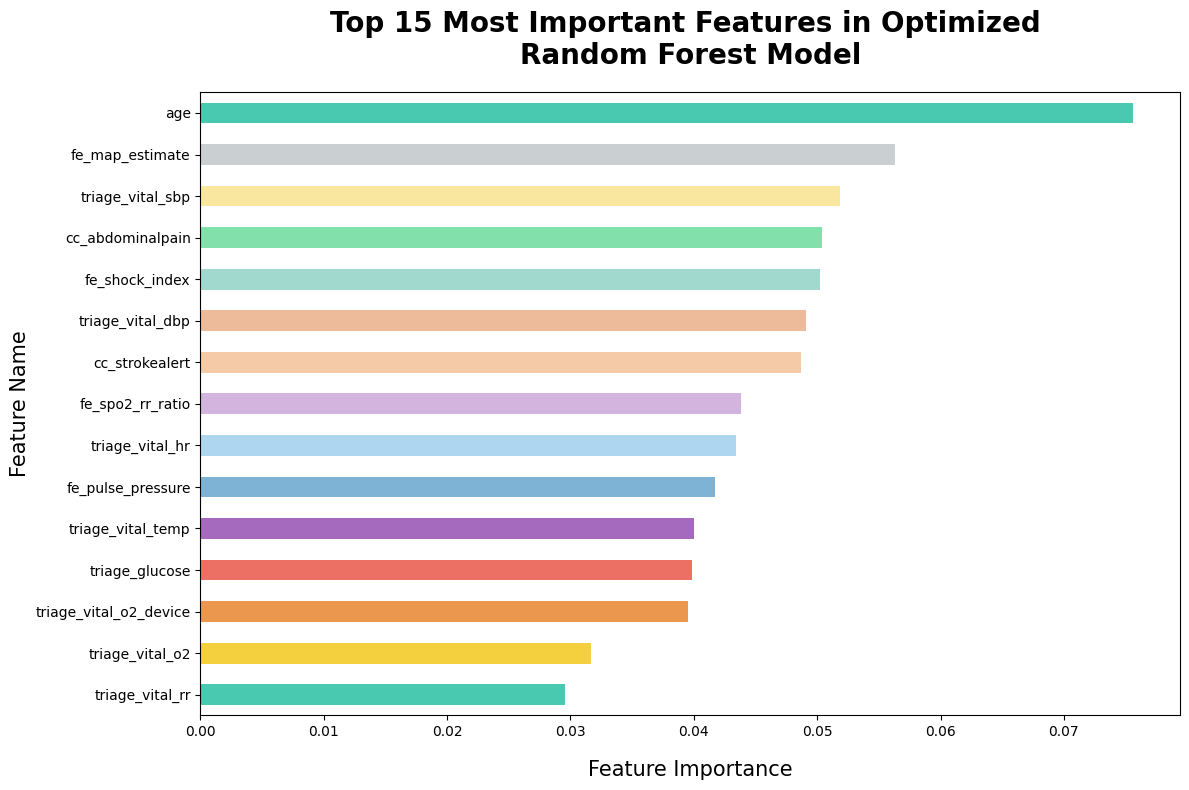

In [83]:
# PLOTTING TOP 10 MOST IMPORTANT FEATURES
feature_importances = pd.Series(rf_best.feature_importances_, index=X_train_plus.columns)

bar_colors = ['#48C9B0', '#F4D03F', '#EB984E', '#EC7063', '#A569BD', '#7FB3D5',
              '#AED6F1', '#D2B4DE', '#F5CBA7', '#EDBB99', '#A2D9CE', '#82E0AA',
              '#F9E79F', '#CACFD2'
            ]

top_15_features = feature_importances.nlargest(15)

plt.figure(figsize=(12, 8))
top_15_features.sort_values(ascending=True).plot(kind='barh', color=bar_colors)
plt.title('Top 15 Most Important Features in Optimized \nRandom Forest Model', fontsize=20, fontweight='bold', y = 1.00, pad=20)
plt.xlabel('Feature Importance', fontsize=15, labelpad=15)
plt.ylabel('Feature Name', fontsize=15)
plt.tight_layout()

plt.savefig("rf_feature_importance.png", dpi=300)
plt.show()

### ***Model 2 - Gradient Boosting Classifier***

In [27]:
"""
param_dist_gb_old = {
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_iter": [50, 100, 150, 200],          #
    "max_depth": [4, 6, 10, 15],
    "min_samples_leaf": [10, 20, 50, 100],
    "l2_regularization": [0.0, 0.1, 1.0, 10.0]
}
"""


'\nparam_dist_gb_old = {\n    "learning_rate": [0.01, 0.05, 0.1, 0.2],\n    "max_iter": [50, 100, 150, 200],          #\n    "max_depth": [4, 6, 10, 15],\n    "min_samples_leaf": [10, 20, 50, 100],\n    "l2_regularization": [0.0, 0.1, 1.0, 10.0]\n}\n'

In [28]:
param_dist_gb = {
    "learning_rate": uniform(0.01, 0.10),  # Controls how aggressively trees correct prior errors
    "max_iter": randint(50, 300),  # Number of sequential trees
    "max_depth": randint(3, 7), # Tree depth limit to prevent overfitting
    "min_samples_leaf": randint(20, 200),
    "l2_regularization": uniform(0.1, 15.0) # Penalizes extreme splits to keep predictions robust
}

search_gb = RandomizedSearchCV(
    estimator=HistGradientBoostingClassifier(
        class_weight="balanced",
        categorical_features="from_dtype",
        random_state=42
    ),
    param_distributions=param_dist_gb,
    n_iter=30,
    cv=3,
    scoring="f1_macro",
    verbose=3
)



print("Starting Gradient Boosting Hyperparameter Search...")
gb_optimized_start = time.perf_counter()
search_gb.fit(X_train_plus, y_train)
gb_optimized = search_gb.best_estimator_
gb_optimized_stop = time.perf_counter()

gb_training_time = gb_optimized_stop - gb_optimized_start

print("Gradient Boosting Hyperparameter Search Complete!")
print("\nBest Gradient Boosting Parameters:", search_gb.best_params_)


Starting Gradient Boosting Hyperparameter Search...
Fitting 3 folds for each of 30 candidates, totalling 90 fits
[CV 1/3] END l2_regularization=9.540157654179412, learning_rate=0.0462152490313243, max_depth=4, max_iter=52, min_samples_leaf=170;, score=0.326 total time=   9.9s
[CV 2/3] END l2_regularization=9.540157654179412, learning_rate=0.0462152490313243, max_depth=4, max_iter=52, min_samples_leaf=170;, score=0.326 total time=   9.2s
[CV 3/3] END l2_regularization=9.540157654179412, learning_rate=0.0462152490313243, max_depth=4, max_iter=52, min_samples_leaf=170;, score=0.315 total time=   9.8s


KeyboardInterrupt: 

In [ ]:
gb_optimized = search_gb.best_estimator_
print(gb_training_time)

In [ ]:
joblib.dump(gb_optimized, "/content/drive/MyDrive/Carisurg_AI_Training_Program/notebooks/week-7/gb_optimized.joblib")
print("Saved gradient boosting securely to Google Drive!")

In [29]:
gb_best = joblib.load("/content/drive/MyDrive/Carisurg_AI_Training_Program/notebooks/week-7/gb_optimized.joblib")
print("Loaded gradient boosting from Google Drive!")

Loaded gradient boosting from Google Drive!


In [30]:
best_params = {
    "l2_regularization": 0.9297544468105483,
    "learning_rate": 0.06851194057778731,
    "max_depth": 6,
    "max_iter": 70,
    "min_samples_leaf": 32,
}

gb_best = HistGradientBoostingClassifier(
    class_weight="balanced",
    categorical_features="from_dtype",
    random_state=42,
    **best_params
)

gb_best.fit(X_train_plus, y_train)

HistGradientBoostingClassifier(class_weight='balanced',
                               l2_regularization=0.9297544468105483,
                               learning_rate=0.06851194057778731, max_depth=6,
                               max_iter=70, min_samples_leaf=32,
                               random_state=42)

### ***Model 3 - Multi-Layer Perceptron Classifier***

In [34]:
from scipy.stats import loguniform, randint
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Define hyperparameter grid (prefixed with 'mlpclassifier__')
param_dist_mlp = {
    "mlpclassifier__alpha": loguniform(1e-4, 1e-1),  # L2 penalty
    "mlpclassifier__hidden_layer_sizes": [
        (64, 32),
        (128, 64),
        (64, 32, 16),
        (32, 16),
    ],
    "mlpclassifier__learning_rate_init": loguniform(1e-4, 1e-2),
}

# Define pipeline with early stopping
mlp_pipeline = make_pipeline(
    StandardScaler(),
    MLPClassifier(
        random_state=42,
        max_iter=200,
        early_stopping=True,  # Stops training when validation score flattens
        n_iter_no_change=10,
        solver="adam",
    ),
)

search_mlp = RandomizedSearchCV(
    estimator=mlp_pipeline,
    param_distributions=param_dist_mlp,
    n_iter=20,
    cv=3,
    scoring="f1_macro",
    verbose=2,
    n_jobs=-1,  # Uses all CPU cores
)

print("Starting MLP Hyperparameter Search...")
mlp_optimized_start = time.perf_counter()
search_mlp.fit(X_train_plus, y_train)
mlp_optimized_stop = time.perf_counter()

mlp_training_time = mlp_optimized_stop - mlp_optimized_start

print("MLP Search Complete!")
print("\nBest MLP Parameters:", search_mlp.best_params_)
print("Best Macro F1 CV Score:", round(search_mlp.best_score_, 4))

# Store best estimator
mlp_optimized = search_mlp.best_estimator_

Starting MLP Hyperparameter Search...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
MLP Search Complete!

Best MLP Parameters: {'mlpclassifier__alpha': np.float64(0.004344352862984686), 'mlpclassifier__hidden_layer_sizes': (128, 64), 'mlpclassifier__learning_rate_init': np.float64(0.00019196436645793288)}
Best Macro F1 CV Score: 0.4944


In [ ]:
"""
Best MLP Parameters: {'mlpclassifier__alpha': np.float64(0.0027433515823323206), 'mlpclassifier__hidden_layer_sizes': (128, 64), 'mlpclassifier__learning_rate_init': np.float64(0.006617460536255102)}
Best Macro F1 CV Score: 0.4992
"""

In [36]:
print(mlp_training_time)

495.9730993349999


In [46]:
pred_mlp = mlp_optimized.predict(X_test_plus_scaled)
print(classification_report(y_test, pred_mlp))

              precision    recall  f1-score   support

           1       0.33      0.31      0.32        16
           2       0.61      0.56      0.58      3585
           3       0.60      0.72      0.65      5402
           4       0.57      0.33      0.42      1779
           5       0.37      0.23      0.28       243

    accuracy                           0.60     11025
   macro avg       0.50      0.43      0.45     11025
weighted avg       0.59      0.60      0.58     11025



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [47]:
joblib.dump(mlp_optimized, "/content/drive/MyDrive/Carisurg_AI_Training_Program/notebooks/week-7/mlp_optimized.joblib")
print("Saved mlp securely to Google Drive!")

Saved mlp securely to Google Drive!


In [48]:
mlp_best = joblib.load("/content/drive/MyDrive/Carisurg_AI_Training_Program/notebooks/week-7/mlp_optimized.joblib")
print("Loaded mlp from Google Drive!")

Loaded mlp from Google Drive!


## **Evaluating Accuracy, Precision, Recall and F1-Score of trained Machine Learning Models**

In [49]:
print("Best Random Forest Model Classification Report:")
print(classification_report(y_test, rf_best.predict(X_test_plus)))


print("\nBest GB Model Classification Report:")
print(classification_report(y_test, gb_best.predict(X_test_plus)))

print("\nBest MLP Model Classification Report:")
print(classification_report(y_test, mlp_best.predict(X_test_plus)))


Best Random Forest Model Classification Report:
              precision    recall  f1-score   support

           1       0.25      0.25      0.25        16
           2       0.63      0.70      0.66      3585
           3       0.74      0.48      0.58      5402
           4       0.43      0.70      0.53      1779
           5       0.20      0.47      0.28       243

    accuracy                           0.59     11025
   macro avg       0.45      0.52      0.46     11025
weighted avg       0.64      0.59      0.59     11025


Best GB Model Classification Report:
              precision    recall  f1-score   support

           1       0.11      0.38      0.17        16
           2       0.65      0.67      0.66      3585
           3       0.76      0.47      0.58      5402
           4       0.42      0.69      0.52      1779
           5       0.15      0.61      0.24       243

    accuracy                           0.57     11025
   macro avg       0.42      0.56      0.43  

## **Confusion Matricies of trained Machine Learning Models**

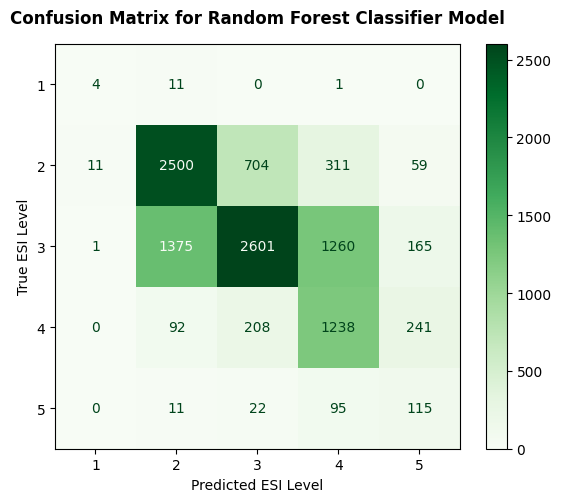

In [80]:
pred_rf = rf_best.predict(X_test_plus)

fig, ax = plt.subplots(figsize=(6, 5))
cm = ConfusionMatrixDisplay.from_predictions(y_test, pred_rf, ax=ax, cmap="Greens", values_format='d')
ax.set_xlabel("Predicted ESI Level")
ax.set_ylabel("True ESI Level")
ax.set_title("Confusion Matrix for Random Forest Classifier Model", fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig("cm_rf.png", dpi=300)
plt.show()

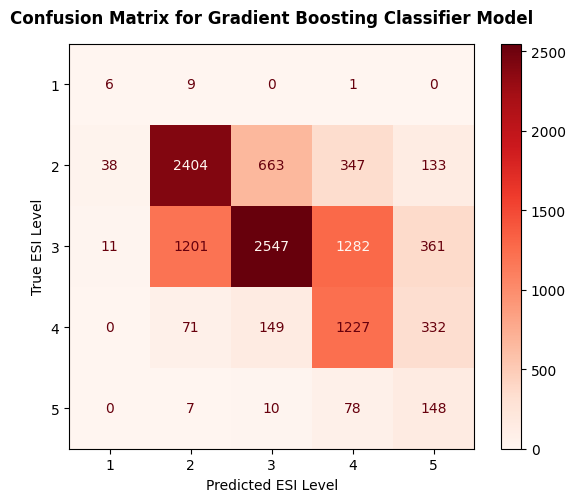

In [81]:
pred_gb = gb_best.predict(X_test_plus)

fig, ax = plt.subplots(figsize=(6, 5))
cm = ConfusionMatrixDisplay.from_predictions(y_test, pred_gb, ax=ax, cmap="Reds", values_format='d')
ax.set_xlabel("Predicted ESI Level")
ax.set_ylabel("True ESI Level")
ax.set_title("Confusion Matrix for Gradient Boosting Classifier Model", fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig("cm_gb.png", dpi=300)
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


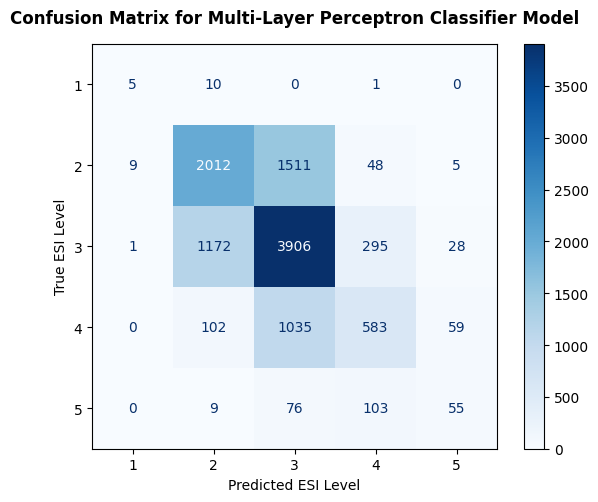

In [82]:
pred_mlp = mlp_best.predict(X_test_plus_scaled)

fig, ax = plt.subplots(figsize=(6, 5))
cm = ConfusionMatrixDisplay.from_predictions(y_test, pred_mlp, ax=ax, cmap="Blues", values_format='d')
ax.set_xlabel("Predicted ESI Level")
ax.set_ylabel("True ESI Level")
ax.set_title("Confusion Matrix for Multi-Layer Perceptron Classifier Model", fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig("cm_mlp.png", dpi=300)
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


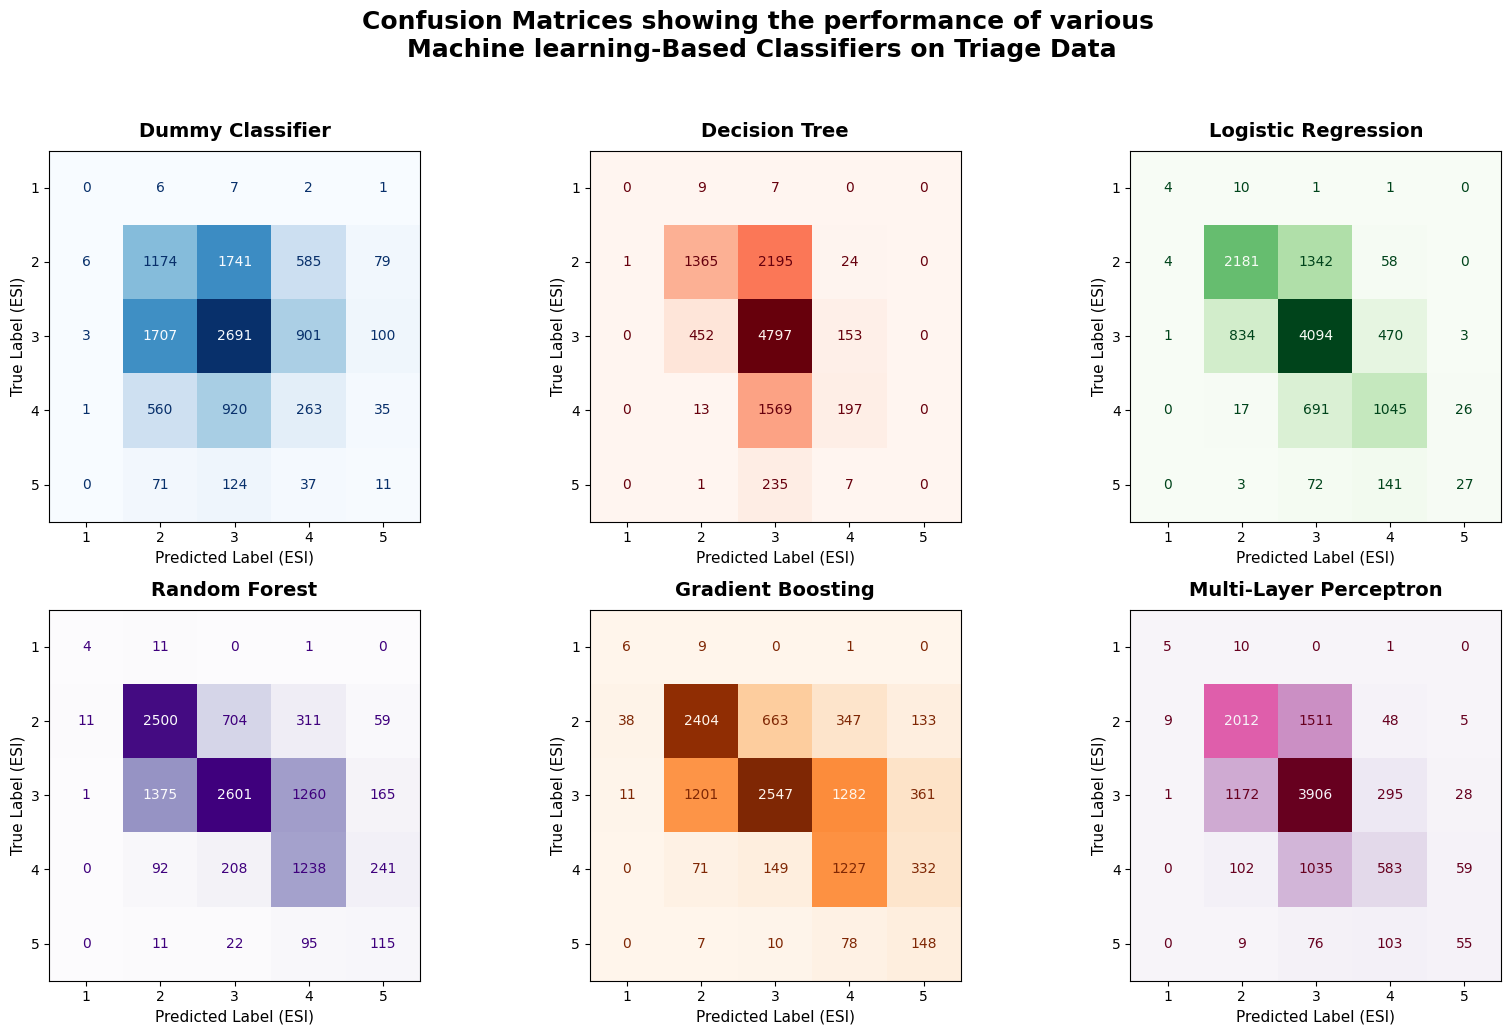

In [85]:
import math
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

models = {
    "Dummy Classifier": dummy,
    "Decision Tree": decision_tree,
    "Logistic Regression": logreg,
    "Random Forest": rf_best,
    "Gradient Boosting": gb_best,
    "Multi-Layer Perceptron": mlp_best,
}

X_test_dict = {
    "Dummy Classifier": X_test,
    "Decision Tree": X_test,
    "Logistic Regression": X_test_scaled,
    "Random Forest": X_test_plus,
    "Gradient Boosting": X_test_plus,
    "Multi-Layer Perceptron": X_test_plus_scaled,
}

color_maps = ["Blues", "Reds", "Greens", "Purples", "Oranges", "PuRd"]


def plot_multipanel_confusion_matrices(models_dict, X_dict, y_true, class_names=None):
    n_models = len(models_dict)
    class_names = [1, 2, 3, 4, 5]

    cols = 3
    rows = 2

    fig, axes = plt.subplots(rows, cols, figsize=(5.5 * cols, 5 * rows))
    axes = np.array(axes).reshape(-1)

    for idx, (name, model) in enumerate(models_dict.items()):
        ax = axes[idx]
        X_data = X_dict.get(name, list(X_dict.values())[0])

        # Predictions
        y_pred = model.predict(X_data)

        # Force labels=[1, 2, 3, 4, 5] so 0-4 mapping doesn't happen
        cm = confusion_matrix(y_true, y_pred, labels=class_names)

        # Plot matrix on assigned subplot
        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm, display_labels=class_names
        )
        disp.plot(
            ax=ax,
            cmap=color_maps[idx],
            colorbar=False,
            values_format="d",
        )

        # Customizing subplots & titles
        ax.set_title(f"{name}", fontsize=14, fontweight="bold", pad=10)
        ax.set_xlabel("Predicted Label (ESI)", fontsize=11)
        ax.set_ylabel("True Label (ESI)", fontsize=11)
        ax.grid(False)

    # Hide unused subplots if grid isn't full
    for idx in range(n_models, len(axes)):
        fig.delaxes(axes[idx])

    plt.suptitle(
        "Confusion Matrices showing the performance of various \nMachine learning-Based Classifiers on Triage Data",
        fontsize=18,
        fontweight="bold",
        y=1.03,
    )
    plt.tight_layout()
    plt.savefig("cm_classifiers.png", dpi=300, bbox_inches="tight")
    plt.show()


plot_multipanel_confusion_matrices(models, X_test_dict, y_test)

## **Benchmarking the Models**

In [53]:
def format_time_period(seconds):
    """Converts a duration in seconds into a human-readable string with an appropriate unit."""
    # Hours
    if seconds >= 3600:
        return f"{seconds / 3600:.2f} hrs"

    # Minutes
    if seconds >= 60:
        return f"{seconds / 60:.2f} mins"

    # Seconds
    if seconds >= 1:
        return f"{seconds:.2f} s"

    # Milliseconds (less than 1 second)
    return f"{seconds * 1000:.2f} ms"

In [76]:
import timeit
import random
import pandas as pd
import numpy as np # Added for consistent array handling
from sklearn.metrics import recall_score, f1_score

def get_benchmark(model_name, model, X_test, y_test, training_time, explainability):

    pred = model.predict(X_test)

    random_idx = random.randint(0, len(X_test) - 1)
    single_sample = X_test.iloc[[random_idx]] if hasattr(X_test, 'iloc') else X_test[[random_idx]]

    inference_time = timeit.timeit(lambda: model.predict(single_sample), number=100) / 100.0

    # Convert multiclass labels to binary for ESI level 1 (1 vs not 1)
    y_test_class1 = (y_test == 1).astype(int)
    pred_class1 = (pred == 1).astype(int)

    benchmark = {
        "Model": model_name,
        "Accuracy": round(model.score(X_test, y_test), 2), # Changed X_test_scaled to X_test (parameter)
        "Recall ESI 1": round(recall_score(y_test_class1, pred_class1), 2),
        "Macro F1": round(f1_score(y_test, pred, average="macro"), 2),
        "Training Time": format_time_period(training_time),
        "Inference Time": format_time_period(inference_time),
        "Explainability": explainability
    }

    return pd.DataFrame([benchmark])

In [78]:
import random
import timeit
import pandas as pd
from sklearn.metrics import f1_score, recall_score

# Collect all benchmark dataframes in a list to prevent empty pd.concat deprecation warnings
benchmarks_list = []

# 1. Dummy Classifier
dummy_benchmark_df = get_benchmark(
    "Dummy Classifier",
    dummy,
    X_test,
    y_test,
    dummy_training_time,
    "N/A. All results are generated randomly.",
)
benchmarks_list.append(dummy_benchmark_df)

# 2. Decision Tree
decisiontree_benchmark_df = get_benchmark(
    "Decision Tree",
    decision_tree,
    X_test,
    y_test,
    decisiontree_training_time,
    "High. A decision chain for each inference can be generated.",
)
benchmarks_list.append(decisiontree_benchmark_df)

# 3. Logistic Regression (Set needs_scaling=1 so feature names stay intact)
logreg_benchmark_df = get_benchmark(
    "Logistic Regression",
    logreg,
    X_test_scaled,
    y_test,
    logreg_training_time,
    "High. The coefficient relating each feature to an increase in ESI can be found.",
)
benchmarks_list.append(logreg_benchmark_df)

# 4. Random Forest
rf_optimized_training_time = 1583.888833
rf_benchmark_df = get_benchmark(
    "Random Forest",
    rf_best,
    X_test_plus,
    y_test,
    rf_optimized_training_time,
    "Medium. Model is harder to interpret than decision tree.",
)
benchmarks_list.append(rf_benchmark_df)

# 5. Gradient Boosting
gb_training_time = 1483.355543091
gb_benchmark_df = get_benchmark(
    "Gradient Boosting",
    gb_best,
    X_test_plus,
    y_test,
    gb_training_time,
    "Medium. Model is harder to interpret than decision tree and random forest.",
)
benchmarks_list.append(gb_benchmark_df)

# 6. Multi-Layer Perceptron
mlp_training_time = 495.9730993349999
mlp_benchmark_df = get_benchmark(
    "Multi-Layer Perceptron",
    mlp_best,
    X_test_plus_scaled,
    y_test,
    mlp_training_time,
    "Low. Neural Networks are notoriously difficult for humans to interpret.",
)
benchmarks_list.append(mlp_benchmark_df)

benchmark_df = pd.concat(benchmarks_list, ignore_index=True)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

In [79]:
benchmark_df

,Model,Accuracy,Recall ESI 1,Macro F1,Training Time,Inference Time,Explainability
0,Dummy Classifier,0.38,0.00,0.20,4.71 ms,0.77 ms,N/A. All results are generated randomly.
1,Decision Tree,0.58,0.00,0.27,534.48 ms,1.92 ms,High. A decision chain for each inference can ...
2,Logistic Regression,0.67,0.25,0.49,9.84 s,0.17 ms,High. The coefficient relating each feature to...
3,Random Forest,0.59,0.25,0.46,26.40 mins,18.97 ms,Medium. Model is harder to interpret than deci...
4,Gradient Boosting,0.57,0.38,0.43,24.72 mins,7.04 ms,Medium. Model is harder to interpret than deci...
5,Multi-Layer Perceptron,0.60,0.31,0.45,8.27 mins,1.23 ms,Low. Neural Networks are notoriously difficult...


## **Final Decision and Future Work**

The **Random Forest** model is recommended for machine learning-based triage due to its low tendency to under-triage patients compared to the other models.

Further research into further optimzing the logistic regression model and random forest model can be done to find a superior classifier. Other algorithms like XGBoost also show promise in the literature and will also be considered

